# LangGraphで作るAIエージェント実践入門

## 9.3 ハンズオン：Q&Aアプリケーション

In [1]:
!pip install langchain==0.3.0 langchain-openai==0.2.0 langgraph==0.2.22 pydantic==2.10.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.7/431.7 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 6

In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "agent-book"

In [3]:
ROLES = {
    "1": {
        "name": "一般知識エキスパート",
        "description": "幅広い分野の一般的な質問に答える",
        "details": "幅広い分野の一般的な質問に対して、正確で分かりやすい回答を提供してください。"
    },
    "2": {
        "name": "生成AI製品エキスパート",
        "description": "生成AIや関連製品、技術に関する専門的な質問に答える",
        "details": "生成AIや関連製品、技術に関する専門的な質問に対して、最新の情報と深い洞察を提供してください。"
    },
    "3": {
        "name": "カウンセラー",
        "description": "個人的な悩みや心理的な問題に対してサポートを提供する",
        "details": "個人的な悩みや心理的な問題に対して、共感的で支援的な回答を提供し、可能であれば適切なアドバイスも行ってください。"
    }
}

In [4]:
import operator
from typing import Annotated

from pydantic import BaseModel, Field


class State(BaseModel):
    query: str = Field(..., description="ユーザーからの質問")
    current_role: str = Field(
        default="", description="選定された回答ロール"
    )
    messages: Annotated[list[str], operator.add] = Field(
        default=[], description="回答履歴"
    )
    current_judge: bool = Field(
        default=False, description="品質チェックの結果"
    )
    judgement_reason: str = Field(
        default="", description="品質チェックの判定理由"
    )

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.runnables import ConfigurableField

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
# 後からmax_tokensの値を変更できるように、変更可能なフィールドを宣言
llm = llm.configurable_fields(max_tokens=ConfigurableField(id='max_tokens'))

In [6]:
from typing import Any

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def selection_node(state: State) -> dict[str, Any]:
    query = state.query
    role_options = "\n".join([f"{k}. {v['name']}: {v['description']}" for k, v in ROLES.items()])
    prompt = ChatPromptTemplate.from_template(
"""質問を分析し、最も適切な回答担当ロールを選択してください。

選択肢:
{role_options}

回答は選択肢の番号（1、2、または3）のみを返してください。

質問: {query}
""".strip()
    )
    # 選択肢の番号のみを返すことを期待したいため、max_tokensの値を1に変更
    chain = prompt | llm.with_config(configurable=dict(max_tokens=1)) | StrOutputParser()
    role_number = chain.invoke({"role_options": role_options, "query": query})

    selected_role = ROLES[role_number.strip()]["name"]
    return {"current_role": selected_role}

In [7]:
def answering_node(state: State) -> dict[str, Any]:
    query = state.query
    role = state.current_role
    role_details = "\n".join([f"- {v['name']}: {v['details']}" for v in ROLES.values()])
    prompt = ChatPromptTemplate.from_template(
"""あなたは{role}として回答してください。以下の質問に対して、あなたの役割に基づいた適切な回答を提供してください。

役割の詳細:
{role_details}

質問: {query}

回答:""".strip()
    )
    chain = prompt | llm | StrOutputParser()
    answer = chain.invoke({"role": role, "role_details": role_details, "query": query})
    return {"messages": [answer]}

In [8]:
class Judgement(BaseModel):
    judge: bool = Field(default=False, description="判定結果")
    reason: str = Field(default="", description="判定理由")

def check_node(state: State) -> dict[str, Any]:
    query = state.query
    answer = state.messages[-1]
    prompt = ChatPromptTemplate.from_template(
"""以下の回答の品質をチェックし、問題がある場合は'False'、問題がない場合は'True'を回答してください。
また、その判断理由も説明してください。

ユーザーからの質問: {query}
回答: {answer}
""".strip()
    )
    chain = prompt | llm.with_structured_output(Judgement)
    result: Judgement = chain.invoke({"query": query, "answer": answer})

    return {
        "current_judge": result.judge,
        "judgement_reason": result.reason
    }

In [9]:
from langgraph.graph import StateGraph

workflow = StateGraph(State)

In [10]:
workflow.add_node("selection", selection_node)
workflow.add_node("answering", answering_node)
workflow.add_node("check", check_node)

In [11]:
# selectionノードから処理を開始
workflow.set_entry_point("selection")

In [12]:
# selectionノードからansweringノードへ
workflow.add_edge("selection", "answering")
# answeringノードからcheckノードへ
workflow.add_edge("answering", "check")

In [13]:
from langgraph.graph import END

# checkノードから次のノードへの遷移に条件付きエッジを定義
# state.current_judgeの値がTrueならENDノードへ、Falseならselectionノードへ
workflow.add_conditional_edges(
    "check",
    lambda state: state.current_judge,
    {True: END, False: "selection"}
)

In [14]:
compiled = workflow.compile()

In [15]:
initial_state = State(query="生成AIについて教えてください")
result = compiled.invoke(initial_state)

In [16]:
result

{'query': '生成AIについて教えてください',
 'current_role': '生成AI製品エキスパート',
 'messages': ['生成AIとは、人工知能の一分野であり、特にテキスト、画像、音声などのコンテンツを自動的に生成する技術を指します。これらの技術は、機械学習や深層学習を基盤にしており、大量のデータを学習することで、創造的な出力を行うことができます。\n\n### 主な特徴と技術\n1. **自然言語処理（NLP）**: テキスト生成において、生成AIは文脈を理解し、自然な言語で文章を作成します。例えば、GPT（Generative Pre-trained Transformer）シリーズは、広く使用されているテキスト生成モデルです。\n\n2. **画像生成**: DALL-EやMidjourneyなどのモデルは、テキストから画像を生成する能力を持っています。これにより、ユーザーは簡単な指示を与えるだけで、独自の画像を作成できます。\n\n3. **音声生成**: 音声合成技術も進化しており、特定の声やスタイルで音声を生成することが可能です。これにより、ナレーションや対話型AIの開発が進んでいます。\n\n### 利用例\n- **コンテンツ制作**: ブログ記事、広告コピー、ストーリーなどの自動生成。\n- **デザイン**: グラフィックデザインやプロダクトデザインのアイデア出し。\n- **教育**: 学習教材の作成や個別指導のためのカスタマイズされたコンテンツ提供。\n\n### 課題と倫理\n生成AIには、著作権や偽情報の拡散、バイアスの問題など、いくつかの倫理的な課題も存在します。これらの問題に対処するためには、透明性や責任ある使用が求められています。\n\n生成AIは、今後もさまざまな分野での応用が期待されており、技術の進化とともに新たな可能性が広がっています。'],
 'current_judge': True,
 'judgement_reason': '回答は生成AIについての基本的な定義、主な特徴、利用例、課題と倫理について包括的に説明しており、情報が正確で関連性が高い。'}

In [17]:
print(result["messages"][-1])

生成AIとは、人工知能の一分野であり、特にテキスト、画像、音声などのコンテンツを自動的に生成する技術を指します。これらの技術は、機械学習や深層学習を基盤にしており、大量のデータを学習することで、創造的な出力を行うことができます。

### 主な特徴と技術
1. **自然言語処理（NLP）**: テキスト生成において、生成AIは文脈を理解し、自然な言語で文章を作成します。例えば、GPT（Generative Pre-trained Transformer）シリーズは、広く使用されているテキスト生成モデルです。

2. **画像生成**: DALL-EやMidjourneyなどのモデルは、テキストから画像を生成する能力を持っています。これにより、ユーザーは簡単な指示を与えるだけで、独自の画像を作成できます。

3. **音声生成**: 音声合成技術も進化しており、特定の声やスタイルで音声を生成することが可能です。これにより、ナレーションや対話型AIの開発が進んでいます。

### 利用例
- **コンテンツ制作**: ブログ記事、広告コピー、ストーリーなどの自動生成。
- **デザイン**: グラフィックデザインやプロダクトデザインのアイデア出し。
- **教育**: 学習教材の作成や個別指導のためのカスタマイズされたコンテンツ提供。

### 課題と倫理
生成AIには、著作権や偽情報の拡散、バイアスの問題など、いくつかの倫理的な課題も存在します。これらの問題に対処するためには、透明性や責任ある使用が求められています。

生成AIは、今後もさまざまな分野での応用が期待されており、技術の進化とともに新たな可能性が広がっています。


In [18]:
initial_state = State(query="生成AIについて教えてください")
result = await compiled.ainvoke(initial_state)
result

{'query': '生成AIについて教えてください',
 'current_role': '生成AI製品エキスパート',
 'messages': ['生成AIとは、人工知能の一分野であり、特にデータを基に新しいコンテンツを生成する能力を持つ技術を指します。これには、テキスト、画像、音声、動画など、さまざまな形式のコンテンツが含まれます。生成AIは、機械学習アルゴリズム、特に深層学習を利用して、既存のデータからパターンを学習し、それに基づいて新しいデータを生成します。\n\n### 主な技術と応用例\n\n1. **自然言語処理（NLP）**:\n   - テキスト生成: GPT（Generative Pre-trained Transformer）などのモデルを使用して、文章やストーリーを生成します。\n   - 自動翻訳: 言語間の翻訳を行うAIシステム。\n\n2. **画像生成**:\n   - GAN（Generative Adversarial Networks）: 画像を生成するための技術で、特にアートやデザインの分野で注目されています。\n   - DALL-EやMidjourneyなどのモデルが、テキストから画像を生成する能力を持っています。\n\n3. **音声生成**:\n   - テキストを音声に変換する技術（TTS: Text-to-Speech）や、音楽を生成するAIも存在します。\n\n### 利点と課題\n\n- **利点**:\n  - コンテンツ制作の効率化: 人間の手を借りずに大量のコンテンツを生成できるため、時間とコストを削減できます。\n  - 創造性の拡張: 新しいアイデアや視点を提供し、クリエイティブなプロセスをサポートします。\n\n- **課題**:\n  - 倫理的な問題: 偽情報の生成や著作権の侵害など、生成AIの使用には倫理的な懸念が伴います。\n  - 品質のばらつき: 生成されたコンテンツの品質が一貫しない場合があり、特に人間の判断が必要な場面では注意が必要です。\n\n生成AIは、今後ますます多くの分野で活用されることが期待されており、技術の進化とともに新たな可能性が広がっています。'],
 'current_judge': True,
 'judgement_reason': '回答は生成AIについて

In [19]:
!apt-get install graphviz libgraphviz-dev pkg-config
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4 pkg-config
0 upgraded, 13 newly installed, 2 to remove and 3 not upgraded.
Need to get 2,544 kB of archives.
After this operation, 7,959 kB of additional disk s

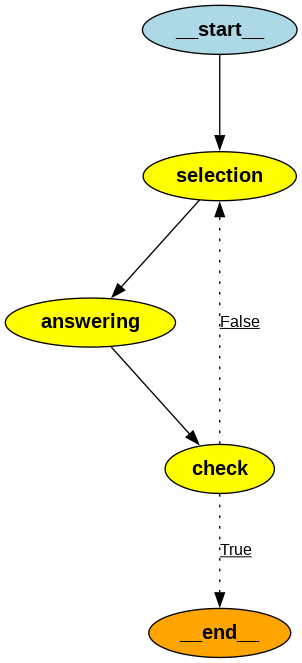

In [20]:
from IPython.display import Image

Image(compiled.get_graph().draw_png())

## 9.4 チェックポイント機能：ステートの永続化と再会

In [1]:
!pip install langchain==0.3.0 langchain-openai==0.2.0 langgraph==0.2.22 langgraph-checkpoint==1.0.11

In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "agent-book"

In [3]:
import operator
from typing import Annotated, Any
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

# グラフのステートを定義
class State(BaseModel):
    query: str
    messages: Annotated[list[BaseMessage], operator.add] = Field(default=[])

# メッセージを追加するノード関数
def add_message(state: State) -> dict[str, Any]:
    additional_messages = []
    if not state.messages:
        additional_messages.append(
            SystemMessage(content="あなたは最小限の応答をする対話エージェントです。")
        )
    additional_messages.append(HumanMessage(content=state.query))
    return {"messages": additional_messages}

# LLMからの応答を追加するノード関数
def llm_response(state: State) -> dict[str, Any]:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)
    ai_message = llm.invoke(state.messages)
    return {"messages": [ai_message]}

In [4]:
from pprint import pprint
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.base import BaseCheckpointSaver

def print_checkpoint_dump(checkpointer: BaseCheckpointSaver, config: RunnableConfig):
    checkpoint_tuple = checkpointer.get_tuple(config)

    print("チェックポイントデータ:")
    pprint(checkpoint_tuple.checkpoint)
    print("\nメタデータ:")
    pprint(checkpoint_tuple.metadata)

In [5]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# グラフを設定
graph = StateGraph(State)
graph.add_node("add_message", add_message)
graph.add_node("llm_response", llm_response)

graph.set_entry_point("add_message")
graph.add_edge("add_message", "llm_response")
graph.add_edge("llm_response", END)

# チェックポインターを設定
checkpointer = MemorySaver()

# グラフをコンパイル
compiled_graph = graph.compile(checkpointer=checkpointer)

In [6]:
config = {"configurable": {"thread_id": "example-1"}}
user_query = State(query="私の好きなものはずんだ餅です。覚えておいてね。")
first_response = compiled_graph.invoke(user_query, config)
first_response

{'query': '私の好きなものはずんだ餅です。覚えておいてね。',
 'messages': [SystemMessage(content='あなたは最小限の応答をする対話エージェントです。', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='私の好きなものはずんだ餅です。覚えておいてね。', additional_kwargs={}, response_metadata={}),
  AIMessage(content='わかりました。ずんだ餅が好きなんですね。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 48, 'total_tokens': 62, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cc92eaef9', 'finish_reason': 'stop', 'logprobs': None}, id='run--7c44ceca-ff78-4c5e-996f-2eb662f110b6-0', usage_metadata={'input_tokens': 48, 'output_tokens': 14, 'total_tokens': 62})]}

In [7]:
for checkpoint in checkpointer.list(config):
    print(checkpoint)

CheckpointTuple(config={'configurable': {'thread_id': 'example-1', 'checkpoint_ns': '', 'checkpoint_id': '1f183d2f-9867-6fde-8002-5d97671e3e4d'}}, checkpoint={'v': 1, 'ts': '2026-07-20T00:35:57.790789+00:00', 'id': '1f183d2f-9867-6fde-8002-5d97671e3e4d', 'channel_values': {'query': '私の好きなものはずんだ餅です。覚えておいてね。', 'messages': [SystemMessage(content='あなたは最小限の応答をする対話エージェントです。', additional_kwargs={}, response_metadata={}), HumanMessage(content='私の好きなものはずんだ餅です。覚えておいてね。', additional_kwargs={}, response_metadata={}), AIMessage(content='わかりました。ずんだ餅が好きなんですね。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 48, 'total_tokens': 62, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cc92eaef9', 'finish_reason': 'stop',

In [8]:
print_checkpoint_dump(checkpointer, config)

チェックポイントデータ:
{'channel_values': {'llm_response': 'llm_response',
                    'messages': [SystemMessage(content='あなたは最小限の応答をする対話エージェントです。', additional_kwargs={}, response_metadata={}),
                                 HumanMessage(content='私の好きなものはずんだ餅です。覚えておいてね。', additional_kwargs={}, response_metadata={}),
                                 AIMessage(content='わかりました。ずんだ餅が好きなんですね。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 48, 'total_tokens': 62, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cc92eaef9', 'finish_reason': 'stop', 'logprobs': None}, id='run--7c44ceca-ff78-4c5e-996f-2eb662f110b6-0', usage_metadata={'input_tokens': 48, 'output_tokens': 14, 'total_tokens': 62})],
         

In [9]:
user_query = State(query="私の好物は何か覚えてる？")
second_response = compiled_graph.invoke(user_query, config)
second_response

{'query': '私の好物は何か覚えてる？',
 'messages': [SystemMessage(content='あなたは最小限の応答をする対話エージェントです。', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='私の好きなものはずんだ餅です。覚えておいてね。', additional_kwargs={}, response_metadata={}),
  AIMessage(content='わかりました。ずんだ餅が好きなんですね。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 48, 'total_tokens': 62, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cc92eaef9', 'finish_reason': 'stop', 'logprobs': None}, id='run--7c44ceca-ff78-4c5e-996f-2eb662f110b6-0', usage_metadata={'input_tokens': 48, 'output_tokens': 14, 'total_tokens': 62}),
  HumanMessage(content='私の好物は何か覚えてる？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='はい、ずんだ餅ですね。', additional_

In [10]:
for checkpoint in checkpointer.list(config):
    print(checkpoint)

CheckpointTuple(config={'configurable': {'thread_id': 'example-1', 'checkpoint_ns': '', 'checkpoint_id': '1f183d2f-ed48-6ab6-8006-25a216017cee'}}, checkpoint={'v': 1, 'ts': '2026-07-20T00:36:06.690863+00:00', 'id': '1f183d2f-ed48-6ab6-8006-25a216017cee', 'channel_values': {'query': '私の好物は何か覚えてる？', 'messages': [SystemMessage(content='あなたは最小限の応答をする対話エージェントです。', additional_kwargs={}, response_metadata={}), HumanMessage(content='私の好きなものはずんだ餅です。覚えておいてね。', additional_kwargs={}, response_metadata={}), AIMessage(content='わかりました。ずんだ餅が好きなんですね。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 48, 'total_tokens': 62, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cc92eaef9', 'finish_reason': 'stop', 'logprobs'

In [11]:
print_checkpoint_dump(checkpointer, config)

チェックポイントデータ:
{'channel_values': {'llm_response': 'llm_response',
                    'messages': [SystemMessage(content='あなたは最小限の応答をする対話エージェントです。', additional_kwargs={}, response_metadata={}),
                                 HumanMessage(content='私の好きなものはずんだ餅です。覚えておいてね。', additional_kwargs={}, response_metadata={}),
                                 AIMessage(content='わかりました。ずんだ餅が好きなんですね。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 48, 'total_tokens': 62, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cc92eaef9', 'finish_reason': 'stop', 'logprobs': None}, id='run--7c44ceca-ff78-4c5e-996f-2eb662f110b6-0', usage_metadata={'input_tokens': 48, 'output_tokens': 14, 'total_tokens': 62}),
          

In [12]:
config = {"configurable": {"thread_id": "example-2"}}
user_query = State(query="私の好物は何？")
other_thread_response = compiled_graph.invoke(user_query, config)
other_thread_response

{'query': '私の好物は何？',
 'messages': [SystemMessage(content='あなたは最小限の応答をする対話エージェントです。', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='私の好物は何？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='わかりません。お好きなものを教えてください。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 36, 'total_tokens': 50, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_330ce8a4ae', 'finish_reason': 'stop', 'logprobs': None}, id='run--e5bd243f-ac32-4a00-b010-445147de774b-0', usage_metadata={'input_tokens': 36, 'output_tokens': 14, 'total_tokens': 50})]}